### This notebook loads the summary of Heart Rate from subjects of Social dataset and looks into systematic differences across tasks

In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import scipy.stats as stats
from statsmodels.stats.anova import AnovaRM

In [2]:
# load HR summary tsv
tsv_path = '/cifs/diedrichsen/data/Cerebellum/Social/data/physio/HR_summary.tsv'
hr_df = pd.read_csv(tsv_path, sep='\t')
hr_df.head()

,subj_id,run_num,task_name,task_code,task_cond,avg_instruction_HR,avg_task_HR
0,sub-05,1,action_prediction,action_prediction,action_prediction_greeting_hard,57.104500,56.659217
1,sub-05,1,frith_happe,frith_happe,frith_happe_tom,57.615986,57.468941
2,sub-05,1,theory_of_mind,tom,theory_of_mind_belief,59.004135,58.739100
3,sub-05,1,strange_stories,strange_stories,strange_stories_social,59.347420,58.251872
4,sub-05,1,liking,liking,liking_like,58.661684,59.130879


In [3]:
# Make sure 'task_cond' is categorical
hr_df['task_cond'] = hr_df['task_cond'].astype('category')

# Reorder categories so 'rest' is first (the reference)
categories = ['rest'] + [t for t in hr_df['task_cond'].cat.categories if t != 'rest']
hr_df['task_cond'] = hr_df['task_cond'].cat.reorder_categories(categories, ordered=True)

# Average across all subjects & runs
task_means = hr_df.groupby('task_cond')[["avg_instruction_HR", "avg_task_HR"]].mean()
print(task_means)

                                 avg_instruction_HR  avg_task_HR
task_cond                                                       
rest                                      65.150072    63.642846
action_prediction_greeting_hard           65.297235    64.586073
action_prediction_soccer_hard             66.108981    65.229472
demand_grid                               65.395849    65.911900
faux_pas_control                          65.471500    65.178954
faux_pas_social                           65.513528    65.122506
frith_happe_random                        65.898400    64.341467
frith_happe_tom                           65.322472    63.360797
liking_control                            65.861918    64.719553
liking_like                               65.573935    64.897375
picture_sequence_control                  65.640026    64.427952
picture_sequence_fbelief                  65.863682    64.627481
rmet_age                                  65.495889    64.671745
rmet_emotion             

In [4]:
# Instruction vs Task average HR t-test
t_stat, p_val = stats.ttest_rel(hr_df["avg_instruction_HR"], hr_df["avg_task_HR"])
print(f"Paired t-test: t={t_stat:.3f}, p={p_val:.3g}")

Paired t-test: t=15.588, p=3.69e-52


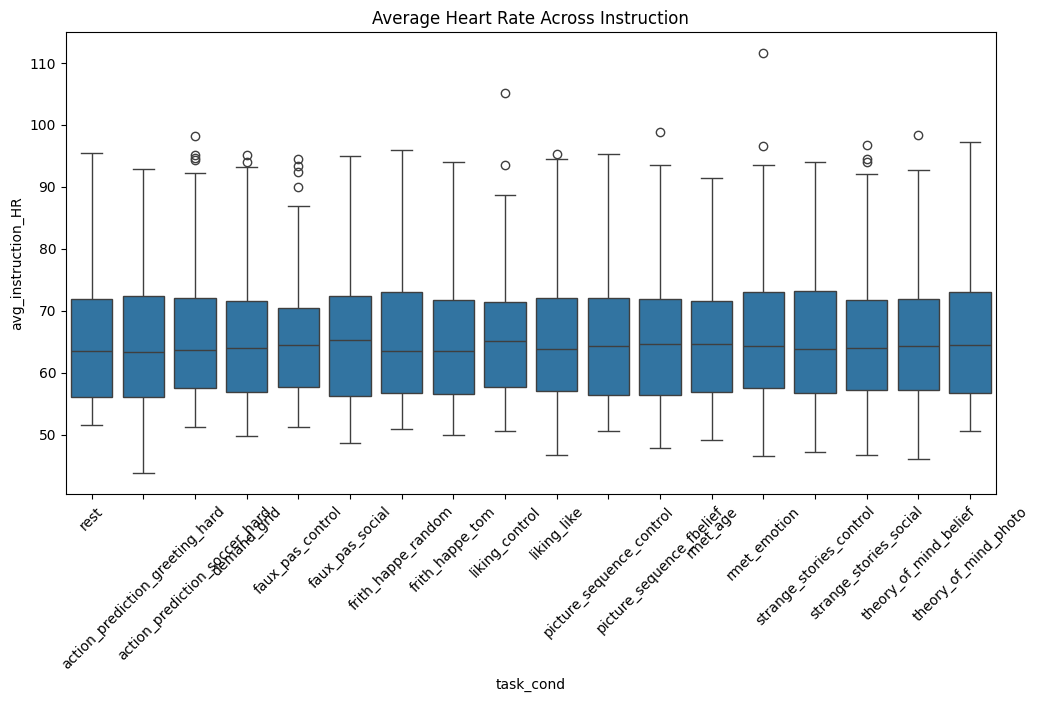

In [5]:
plt.figure(figsize=(12, 6))
sns.boxplot(x='task_cond', y="avg_instruction_HR", data=hr_df)
plt.title("Average Heart Rate Across Instruction")
plt.xticks(rotation=45)
plt.show()

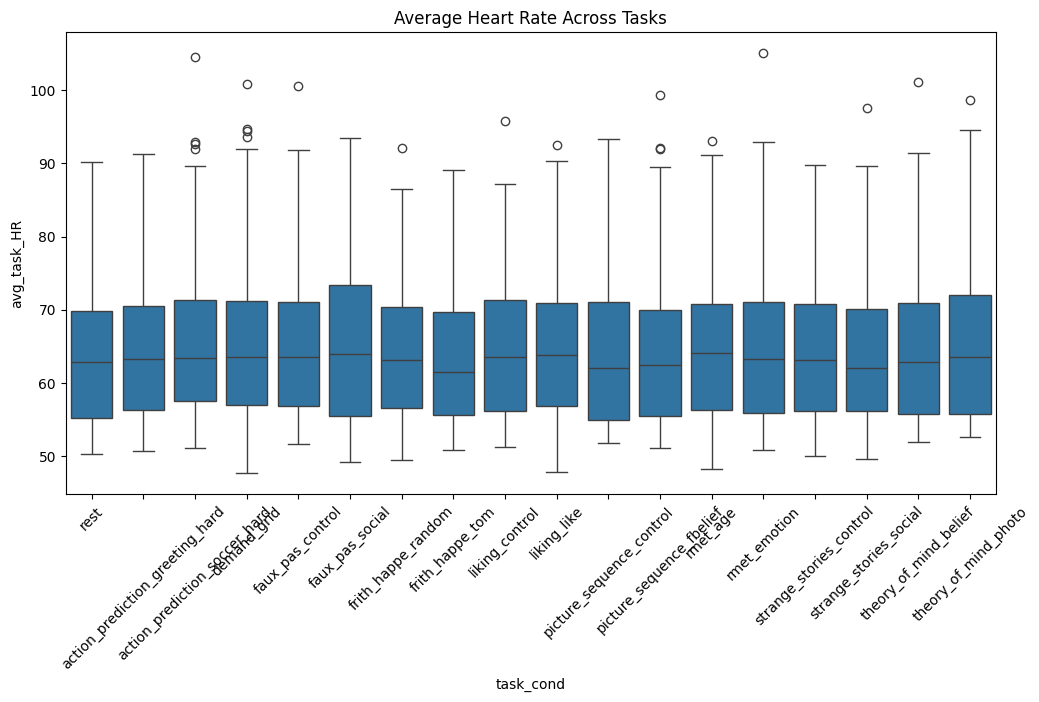

In [6]:
plt.figure(figsize=(12, 6))
sns.boxplot(x='task_cond', y="avg_task_HR", data=hr_df)
plt.title("Average Heart Rate Across Tasks")
plt.xticks(rotation=45)
plt.show()

In [ ]:
# Average HR across runs per subject per task
subject_task_avg = hr_df.groupby(['subj_id','task_cond'])['avg_task_HR'].mean().reset_index()

aov = AnovaRM(
    data=subject_task_avg,
    depvar="avg_task_HR",   # dependent variable
    subject="subj_id",      # repeated measure identifier
    within=['task_cond']    # within-subject factors
).fit()

print(aov)

                  Anova
          F Value  Num DF  Den DF  Pr > F
-----------------------------------------
task_cond  3.1222 17.0000 255.0000 0.0000

